In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize,
    RandomHorizontalFlip, RandomRotation,
    ColorJitter, RandomResizedCrop,
    GaussianBlur
)
from torch.utils.data import Dataset
from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
    ViTConfig,
    TrainingArguments,
    Trainer, EarlyStoppingCallback)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
Image.MAX_IMAGE_PIXELS=None

e:\CS 180 CNN\vit_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# convert to hugging face
class HFImageDataset(Dataset):
    def __init__(self, folder_dataset):
        self.ds = folder_dataset

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, label = self.ds[idx]
        return {
            "pixel_values": image.float(),
            "labels": torch.tensor(label)
        }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [3]:
# base_path = r"E:\CS 180 CNN\AI vs Human 2025 Data"
# train_csv_path = os.path.join(base_path, "train.csv")
# train_df = pd.read_csv(train_csv_path)
# train_df['file_name'] = base_path + "\\train_data\\" + train_df['file_name'].astype(str)

asa_base = r"E:\CS 180 CNN\asa-real-fake-dataset\versions\4\Final Dataset"
old_train_real_dir = os.path.join(asa_base, "Train", "Train_Real")
old_train_fake_dir = os.path.join(asa_base, "Train", "Train_Fake")
old_test_real_dir = os.path.join(asa_base, "Test", "Test_Real")
old_test_fake_dir = os.path.join(asa_base, "Test", "Test_Fake")

def get_paths(directory):
    return [os.path.join(directory, f) for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

df_old_train_real = pd.DataFrame({'file_name': get_paths(old_train_real_dir), 'label': 0})
df_old_train_fake = pd.DataFrame({'file_name': get_paths(old_train_fake_dir), 'label': 1})
df_old_test_real = pd.DataFrame({'file_name': get_paths(old_test_real_dir), 'label': 0})
df_old_test_fake = pd.DataFrame({'file_name': get_paths(old_test_fake_dir), 'label': 1})

master_df = pd.concat([
    # train_df, 
    df_old_train_real, df_old_train_fake,
    df_old_test_real, df_old_test_fake
], ignore_index=True)

# remove missing labels
master_df = master_df.dropna(subset=['label'])
master_df['label'] = master_df['label'].astype(int)

# 80-20 split
train_df_final, val_df_final = train_test_split(
    master_df, test_size=0.2, random_state=42, stratify=master_df['label']
)
print(f"Training Images: {len(train_df_final)}")
print(f"Testing Images: {len(val_df_final)}")

Training Images: 8000
Testing Images: 2000


In [4]:
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

# data augmentation
train_transforms = Compose([
    RandomResizedCrop(224, scale=(0.8, 1.0)),
    RandomHorizontalFlip(p=0.5),
    RandomRotation(degrees=10),
    # ColorJitter(
    #     brightness=0.2,
    #     contrast=0.2,
    #     saturation=0.2,
    #     hue=0.1
    # ),
    # GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    ToTensor(),
    Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    )
])

test_transforms = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=processor.image_mean, std=processor.image_std)
])

In [5]:
class VeritasDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'file_name']
        label = self.dataframe.loc[idx, 'label']
        
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            image = Image.new('RGB', (224, 224))
            
        if self.transform:
            image = self.transform(image)
            
        return {
            'pixel_values': image,
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_ds = VeritasDataset(train_df_final, transform=train_transforms)
test_ds = VeritasDataset(val_df_final, transform=test_transforms)
class_names = ['Real', 'Fake']


In [6]:
# Uncomment if base ViT doesn't produce good results
# config = ViTConfig.from_pretrained(
#     "google/vit-large-patch16-224"
# )

# modify the number of self attention layers, ViT base is initially 12.
# ViT large has 24 layers
# config.num_hidden_layers = 24

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    # config=config,
    num_labels=len(class_names),
    id2label={0: "real", 1: "fake"},
    label2id={"real": 0,"fake":1},
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 3660.93it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [7]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,

    learning_rate=1e-5,
    weight_decay=0.05,
    warmup_steps=500,

    num_train_epochs=3,
    logging_steps=10,
    load_best_model_at_end=True,      # Enable early stopping
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    warmup_ratio=0.1,             # first 10% for warm up
    lr_scheduler_type="cosine",   # slowly adjust learning rate
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.395881,0.482214,0.787000
2,0.248429,0.409357,0.827000
3,0.236364,0.408517,0.826000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.03it/s]


TrainOutput(global_step=1500, training_loss=0.3847626034418742, metrics={'train_runtime': 4012.6699, 'train_samples_per_second': 5.981, 'train_steps_per_second': 0.374, 'total_flos': 1.859807750750208e+18, 'train_loss': 0.3847626034418742, 'epoch': 3.0})

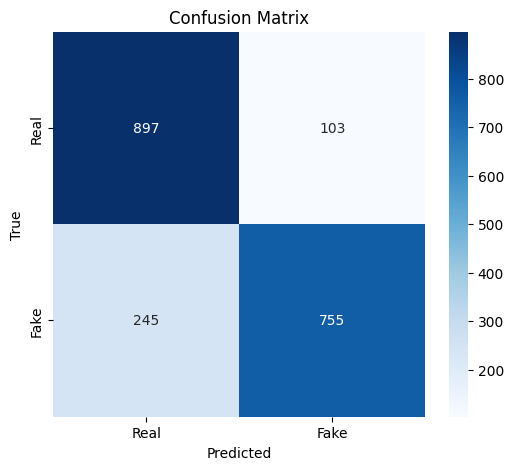

              precision    recall  f1-score   support

        Real       0.79      0.90      0.84      1000
        Fake       0.88      0.76      0.81      1000

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000

Precision: [0.7854641  0.87995338]
Recall: [0.897 0.755]
F1: [0.83753501 0.81270183]


In [8]:
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
labels = pred_output.label_ids

preds = np.argmax(logits, axis=1)
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(labels, preds, target_names=class_names))

precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

In [9]:
import torch
print(torch.cuda.is_available())

True


In [11]:
# Create a specific folder name so you remember what this version is
backup_folder = "./Veritas_ViT_Gen3"
trainer.save_model(backup_folder)
processor.save_pretrained(backup_folder)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.78s/it]


['./Veritas_ViT_Gen3\\preprocessor_config.json']